# Non-linear feature engineering for Linear Regression

### Learning Objectives

In this notebook we learn to:

1. Distinguish between linear and non-linear relationships
2. Fit non-linear patterns using non-linear models
3. Fit non-linear patterns using linear models with `PolynomialFeatures`
4. Fit non-linear patterns using linear models with `SplineTransformer`
5. Recognize Decision Trees and Support Vector Machines as non-linear models 

In this notebook, we show that even if linear models are not natively adapted to express a `target` that is not a linear function of the `data`, it is still possible to make linear models more expressive by engineering additional features.

A machine learning pipeline that combines a non-linear feature engineering step followed by a linear regression step can therefore be considered a non-linear regression model as a whole.

In this occasion we are not loading a dataset, but creating our own custom data consisting of a single feature. The target is built as a cubic polynomial on said feature. To make things a bit more challenging, we add some random fluctuations to the target.

In [1]:
import numpy as np

rng = np.random.RandomState(0)

n_sample = 100
data_max, data_min = 1.4, -1.4
len_data = data_max - data_min
# sort the data to make plotting easier later
data = np.sort(rng.rand(n_sample) * len_data - len_data / 2)
noise = rng.randn(n_sample) * 0.3
target = data**3 - 0.5 * data**2 + noise

::: {.callout-tip}
`np.random.RandomState` allows creating a random number generator which can be later used to get deterministic results.
:::

To ease the plotting, we create a pandas dataframe containing the data and target:

In [2]:
import pandas as pd

full_data = pd.DataFrame({
    "input_feature": data,
    "target": target
})

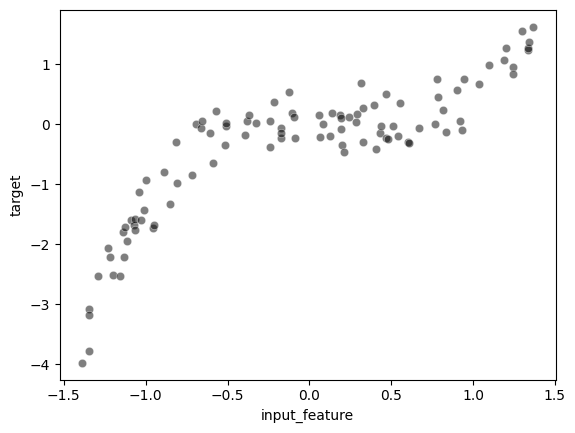

In [3]:
import seaborn as sns

_ = sns.scatterplot(
    data=full_data,
    x="input_feature",
    y="target",
    color="black",
    alpha=0.5
)
import matplotlib.pyplot as plt
plt.gcf().savefig("../assets/non_linear_scatter_data.png", bbox_inches="tight", dpi=150)

::: {.callout-warning}

In scikit-learn, by convention `data` (also called `X` in the scikit-learn documentation) should be a 2D matrix of shape `(n_samples, n_features)`. If `data` is a 1D vector, you need to reshape it into a matrix with a single column if the vector represents a feature or a single row if the vector represents a sample.

:::

In [4]:
# X should be 2D for sklearn: (n_samples, n_features)
data = data.reshape((-1, 1))
data.shape

(100, 1)

To avoid writing the same code in multiple places we define a helper function that fits, scores and plots the different regression models.

In [5]:
from sklearn.metrics import mean_squared_error


def fit_score_plot_regression(model, title=None, save_path=None):
    import matplotlib.pyplot as plt
    model.fit(data, target)
    target_predicted = model.predict(data)
    mse = mean_squared_error(target, target_predicted)
    ax = sns.scatterplot(
        data=full_data, x="input_feature", y="target", color="black", alpha=0.5
    )
    ax.plot(data, target_predicted)
    if title is not None:
        _ = ax.set_title(title + f" (MSE = {mse:.2f})")
    else:
        _ = ax.set_title(f"Mean squared error = {mse:.2f}")
    if save_path:
        plt.gcf().savefig(save_path, bbox_inches="tight", dpi=150)


We now observe the limitations of fitting a linear regression model.

In [6]:
from sklearn.linear_model import LinearRegression

linear_regression = LinearRegression()
linear_regression

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


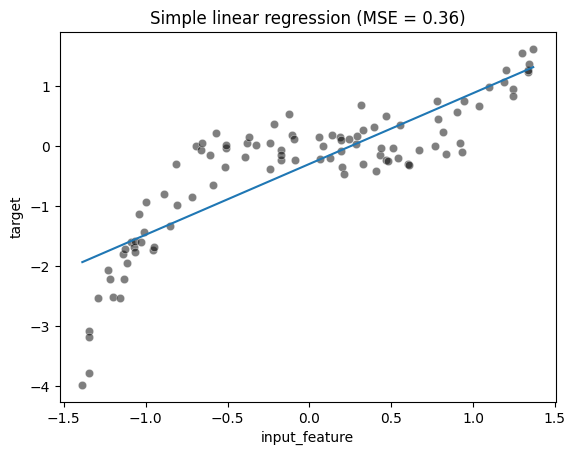

In [7]:
fit_score_plot_regression(
    linear_regression,
    title="Simple linear regression",
    save_path="../assets/non_linear_linear_regression.png",
)

Here the coefficient and intercept learnt by `LinearRegression` define the best "straight line" that fits the data. We can inspect the coefficients using the attributes of the model learnt as follows:

In [8]:
print(
    f"weight: {linear_regression.coef_[0]:.2f}\n"
    f"intercept: {linear_regression.intercept_:.2f}"
)

weight: 1.18
intercept: -0.29


Notice that the learnt model cannot handle the non-linear relationship between `data` and `target` because linear models assume a linear relationship. Indeed, there are 3 possibilities to solve this issue:

1. choose a model that can natively deal with non-linearity,
2. engineer a richer set of features by including expert knowledge which can    be directly used by a simple linear model, or
3. use a "kernel" to have a locally-based decision function instead of a    global linear decision function.

### 1. Non-linear model: Decision Tree

Let's illustrate quickly the first point by using a decision tree regressor which can natively handle non-linearity.


In [9]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(max_depth=3)
tree.fit(data, target)
tree

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_le

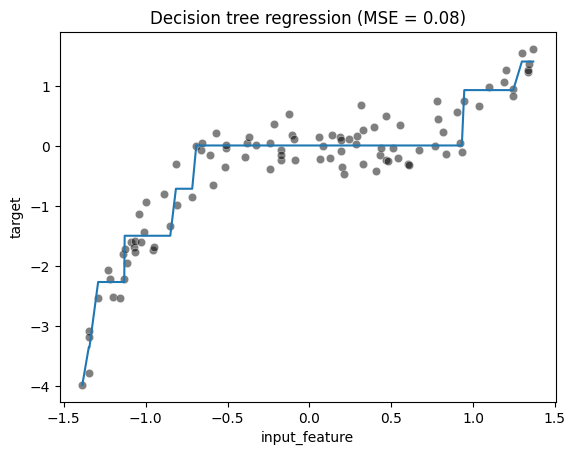

In [10]:
fit_score_plot_regression(
    tree,
    title="Decision tree regression",
    save_path="../assets/non_linear_decision_tree.png",
)

### 2. Engineer Polynomial Features

Instead of having a model which can natively deal with non-linearity, we could also modify our data: we could create new features, derived from the original features, using some expert knowledge. In this example, we know that we have a cubic and squared relationship between `data` and `target` (because we generated the data).

Indeed, we could create two new features (`data ** 2` and `data ** 3`) using this information as follows. This kind of transformation is called a polynomial feature expansion:

In [11]:
data.shape

(100, 1)

In [12]:
data_expanded = np.concatenate([data, data**2, data**3], axis=1)
data_expanded.shape

(100, 3)

Instead of manually creating such polynomial features one could directly use [sklearn.preprocessing.PolynomialFeatures](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html).

In [13]:
from sklearn.preprocessing import PolynomialFeatures

polynomial_expansion = PolynomialFeatures(
    degree=3,
    include_bias=False
)

::: {.callout-note}

In the previous cell we had to set `include_bias=False` as otherwise we would create a constant feature perfectly correlated to the `intercept_` introduced by the `LinearRegression`.

:::

We can verify that this procedure is equivalent to creating the features by hand up to numerical error by computing the maximum of the absolute values of the differences between the features generated by both methods and checking that it is close to zero:

In [14]:
np.abs(polynomial_expansion.fit_transform(data) - data_expanded).max()

np.float64(2.220446049250313e-16)

To demonstrate the use of the `PolynomialFeatures` class, we use a scikit-learn pipeline which first transforms the features and then fit the regression model.

In [15]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

polynomial_regression = make_pipeline(
    PolynomialFeatures(degree=3, include_bias=False),
    LinearRegression(),
)
polynomial_regression

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('polynomialfeatures', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",3
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06


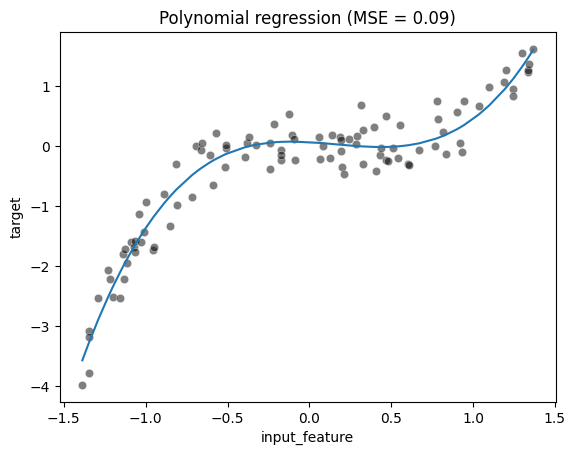

In [16]:
fit_score_plot_regression(
    polynomial_regression,
    title="Polynomial regression",
    save_path="../assets/non_linear_polynomial_regression.png",
)

We can see that even with a linear model, we can overcome the linearity limitation of the model by adding the non-linear components in the design of additional features. Here, we created new features by knowing the way the target was generated.

### 3. Use a Kernel

The last possibility is to make a linear model more expressive is to use a "kernel". Instead of learning one weight per feature as we previously did, a weight is assigned to each sample. However, not all samples are used: some redundant data points of the training set are assigned a weight of 0 so that they do no influence the model's prediction function. This is the main intuition of the support vector machine algorithm.

The mathematical definition of "kernels" and "support vector machines" is beyond the scope of this course. We encourage interested readers with a mathematical training to have a look at the scikit-learn [documentation on SVMs](https://scikit-learn.org/stable/modules/svm.html) for more details.

For the rest of us, let us just develop some intuitions on the relative expressive power of support vector machines with linear and non-linear kernels by fitting them on the same dataset.

First, consider a support vector machine with a linear kernel:

In [17]:
from sklearn.svm import SVR

svr = SVR(kernel="linear")
svr

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


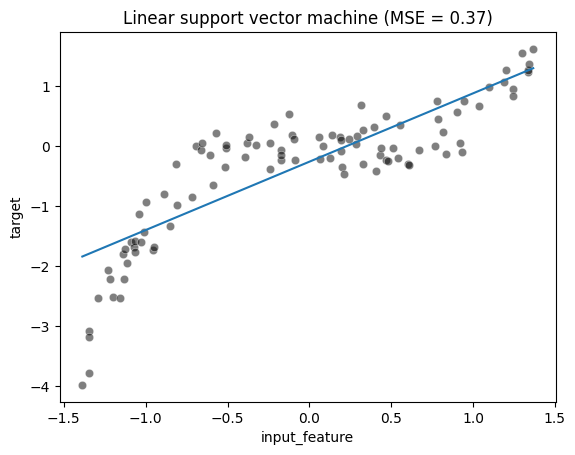

In [18]:
fit_score_plot_regression(
    svr,
    title="Linear support vector machine",
    save_path="../assets/non_linear_svr_linear.png",
)

The predictions of our SVR with a linear kernel are all aligned on a straight line. `SVR(kernel="linear")` is indeed yet another example of a linear model.

The estimator can also be configured to use a non-linear kernel. Then, it can learn a prediction function that computes non-linear relations between samples for which we want to make a prediction and selected samples from the training set.

The result is another kind of non-linear regression model with a similar expressivity as our previous polynomial regression pipeline:

In [19]:
svr = SVR(kernel="poly", degree=3)
svr

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'poly'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


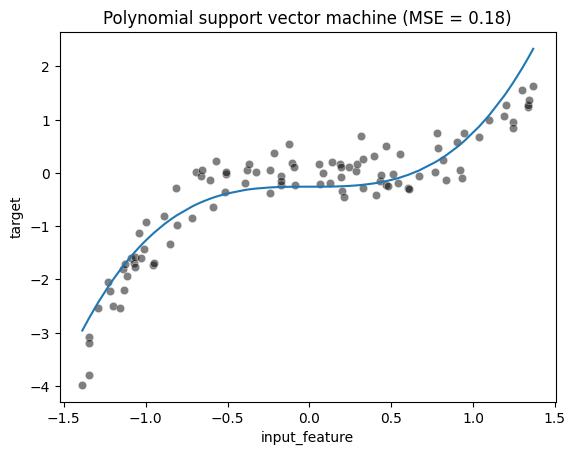

In [20]:
fit_score_plot_regression(
    svr,
    title="Polynomial support vector machine",
    save_path="../assets/non_linear_svr_polynomial.png",
)

### 4. Non-linear feature transformers

Kernel methods such as SVR are very efficient for small to medium datasets.

For larger datasets with `n_samples >> 10_000`, it is often computationally more efficient to perform explicit feature expansion using `PolynomialFeatures` or other non-linear transformers from scikit-learn such as [KBinsDiscretizer](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.KBinsDiscretizer.html) or [SplineTransformer](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.SplineTransformer.html).

Regression splines involve dividing the range of a feature X into K distinct regions (by using so called knots). Within each region, a polynomial function (also called a Basis Spline or B-splines) is fit to the data. In the following example, various piecewise polynomials are fit to the data, with one knot at age=50 [James et al., 2021]:

![Figure: Spline Regressino plots at age 50](../assets/spline_regression.png)

See: [Regression Splines | kirenz](https://kirenz.github.io/regression/docs/splines.html).

Here again we refer the interested reader to the documentation to get a proper definition of those methods. The following just gives an intuitive overview of the predictions we would get using those on our toy dataset:

In [21]:
from sklearn.preprocessing import SplineTransformer

spline_regression = make_pipeline(
    SplineTransformer(
        n_knots=5,
        degree=3,
        include_bias=False
    ),
    LinearRegression(),
)
spline_regression

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('splinetransformer', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"n_knots n_knots: int, default=5Number of knots of the splines if `knots` equals one of{'uniform', 'quantile'}. Must be larger or equal 2. Ignored if `knots`is array-like.",5
,"degree degree: int, default=3The polynomial degree of the spline basis. Must be a non-negativeinteger.",3
,"knots knots: {'uniform', 'quantile'} or array-like of shape (n_knots, n_features), default='uniform'Set knot positions such that first knot <= features <= last knot.- If 'uniform', `n_knots` number of knots are distributed uniformly from min to max values of the features.- If 'quantile', they are distributed uniformly along the quantiles of the features.- If an array-like is given, it directly specifies the sorted knot positions including the boundary knots. Note that, internally, `degree` number of knots are added before the first knot, the same after the last knot.",'uniform'
,"extrapolation extrapolation: {'error', 'constant', 'linear', 'continue', 'periodic'}, default='constant'If 'error', values outside the min and max values of the trainingfeatures raises a `ValueError`. If 'constant', the value of thesplines at minimum and maximum value of the features is used asconstant extrapolation. If 'linear', a linear extrapolation is used.If 'continue', the splines are extrapolated as is, i.e. option`extrapolate=True` in :class:`scipy.interpolate.BSpline`. If'periodic', periodic splines with a periodicity equal to the distancebetween the first and last knot are used. Periodic splines enforceequal function values and derivatives at the first and last knot.For example, this makes it possible to avoid introducing an arbitraryjump between Dec 31st and Jan 1st in spline features derived from anaturally periodic ""day-of-year"" input feature. In this case it isrecommended to manually set the knot values to control the period.",'constant'
,"include_bias include_bias: bool, default=TrueIf False, then the last spline element inside the data rangeof a feature is dropped. As B-splines sum to one over the spline basisfunctions for each data point, they implicitly include a bias term,i.e. a column of ones. It acts as an intercept term in a linear models

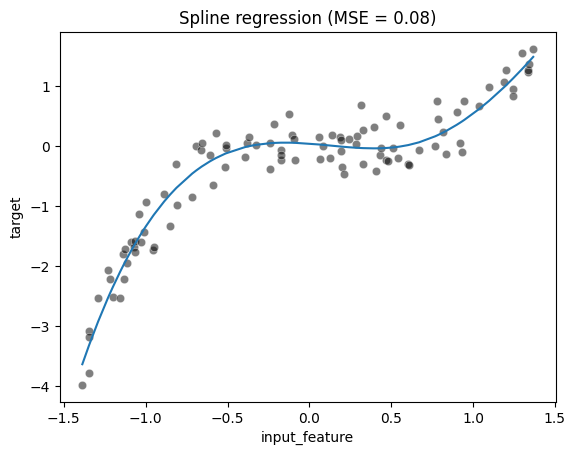

In [22]:
fit_score_plot_regression(
    spline_regression,
    title="Spline regression",
    save_path="../assets/non_linear_spline_regression.png",
)

## Notebook Recap

In this notebook we explored several ways to expand a single numerical feature into several non-linearly derived new features. This makes our machine learning pipeline more expressive and less likely to underfit, even if the last stage of the pipeline is a simple linear regression model.

For the sake of simplicity, we introduced those transformers on a toy regression problem with a single input feature. However, non-linear feature transformers such as Nystroem can further improve the expressiveness of machine learning pipelines to model non-linear interactions between features. We will explore this possibility in the next exercise.